In [2]:
import numpy as np
import pickle
import json
import os
from pathlib import Path
import torch
from sklearn.metrics import precision_recall_curve, roc_curve

DATA_DIR = Path("/global/cfs/cdirs/m3246/gregork")
CKPT_DIR = Path("/global/cfs/cdirs/m3246/gregork/checkpoints")

playlists = ["1A"]

training_names = { # Model -> training name
    "Transformer": "Train_CC1orNPi_Fix250226_20260225_235334",
    #"OmniLearned_Small_PT": "Train_CC1orNPi_Fix250226_PTCont_1A_20260226_033635",
    #"OmniLearned_Small_Cont": "Train_CC1orNPi_Fix250226Cont_1A_20260226_033607"
    "OmniLearned_Small": "Train_CC1orNPi_Fix260226_1A_20260227_085524",
    "OmniLearned_Small_PT": "Train_CC1orNPi_Fix260226_PT_1A_20260227_085634"
}


In [3]:

for key in training_names.keys():
    for playlist in playlists:
        print(f"omnilearned evaluate -i {CKPT_DIR}/{training_names[key]} --num-workers 2 --batch 100")


omnilearned evaluate -i /global/cfs/cdirs/m3246/gregork/checkpoints/Train_CC1orNPi_Fix250226_20260225_235334 --num-workers 2 --batch 100
omnilearned evaluate -i /global/cfs/cdirs/m3246/gregork/checkpoints/Train_CC1orNPi_Fix260226_1A_20260227_085524 --num-workers 2 --batch 100
omnilearned evaluate -i /global/cfs/cdirs/m3246/gregork/checkpoints/Train_CC1orNPi_Fix260226_PT_1A_20260227_085634 --num-workers 2 --batch 100


In [4]:
results = {}
configs = {}
for key in training_names.keys():
    results[key] = {}
    configs[key] = {}
    # File looks like this: CKPT_DIR/training_name/outputs_cont_classification_current_type_<PLAYLIST>_20260204_013605_minerva_<PLAYLIST>_0.npz
    results[key] = {}
    configs[key] = {}
    for playlist in playlists:
        path1 = CKPT_DIR / training_names[key] / "test_results" / f"outputs_{training_names[key]}_minerva_{playlist}_0.npz"
        path2 = CKPT_DIR / training_names[key] / "test_results" / f"outputs_best_model_minerva_{playlist}_0.npz"
        if path1.exists():
            results[key][playlist] = dict(np.load(path1))
        elif path2.exists():
            results[key][playlist] = dict(np.load(path2))
        else:
            raise ValueError(f"No results found for {training_names[key]} on playlist {playlist} - {path1} and {path2} do not exist")
        settings_path = CKPT_DIR / training_names[key] / "settings.json"
        if settings_path.exists():
            configs[key][playlist] = json.load(open(settings_path, "rb"))
        else:
            print(f"No settings found for {training_names[key]} on playlist {playlist}")
            configs[key][playlist] = {}
# softmax the transformer predictions
results["Transformer"]["1A"]["prediction"] = np.exp(results["Transformer"]["1A"]["prediction"]) / np.sum(np.exp(results["Transformer"]["1A"]["prediction"]), axis=1, keepdims=True)

No settings found for Train_CC1orNPi_Fix250226_20260225_235334 on playlist 1A


In [5]:
results["Transformer"]["1A"]["prediction"][0], results["OmniLearned_Small_PT"]["1A"]["prediction"][0], results["Transformer"]["1A"]["pid"][0]

(array([0.1426, 0.1735, 0.25  , 0.362 , 0.0722], dtype=float16),
 array([0.17859061, 0.21969557, 0.2189215 , 0.24167703, 0.14111523],
       dtype=float32),
 np.int64(2))

In [6]:
data_paths = {}
for key in training_names.keys():
    data_paths[key] = {}
    data_paths[key] = {}
    for playlist in playlists:
        data_paths[key][playlist] = {}
        #models[key][model][playlist]["settings"] = configs[key][model][playlist]
        model_path = CKPT_DIR / training_names[key] / "best_model.pt"
        if os.path.exists(model_path):
            data_paths[key][playlist] = torch.load(model_path, weights_only=False, map_location=torch.device("cpu"))["args"]["data_path"]
        else:
            print(f"No best model found for {training_names[key]} on playlist {playlist}")
            del data_paths[key][playlist]

No best model found for Train_CC1orNPi_Fix260226_1A_20260227_085524 on playlist 1A
No best model found for Train_CC1orNPi_Fix260226_PT_1A_20260227_085634 on playlist 1A


In [7]:
truth_labels = {}
default_model = "Transformer"
for key in data_paths[default_model].keys():
    truth_labels[key] = torch.load(open(Path(data_paths[default_model][key]) /  key / "test" / "0.pb", "rb"), weights_only=False, map_location=torch.device("cpu"))["truth_labels"]

In [8]:
def get_CC1orNPi_labels(file_truth_labels):
    # Generate labels for CC 1pi or n pions, according to signal definition in Eberly et al. 2015, on the fly
    is_cc = file_truth_labels[:, 3] == 1
    n_pi_plus = file_truth_labels[:, 5]
    n_pi_minus = file_truth_labels[:, 6]
    labels = torch.zeros(len(file_truth_labels), dtype=torch.long)
    one_pi_plus = n_pi_plus == 1
    one_pi_minus = n_pi_minus == 1
    multi_pions = (n_pi_plus + n_pi_minus) > 1
    labels[is_cc & one_pi_plus & ~one_pi_minus] = 0 # CC 1pi+
    labels[is_cc & one_pi_minus & ~one_pi_plus] = 1 # CC 1pi-
    labels[is_cc & multi_pions] = 2 # CC N Pi +-
    labels[~is_cc] = 3 # Not CC
    labels[is_cc & ((n_pi_plus + n_pi_minus) == 0)] = 4 # CC other
    return labels # labels: 0=CC 1pi+, 1=CC 1pi-, 2=CC N charged pions-, 3=OTHER

truth_labels_class = get_CC1orNPi_labels(truth_labels["1A"])

In [9]:
results["Transformer"]["1A"]["prediction"][2], results["OmniLearned_Small_PT"]["1A"]["prediction"][2]

(array([0.307   , 0.2485  , 0.2935  , 0.000461, 0.1508  ], dtype=float16),
 array([0.3724405 , 0.21067593, 0.17173345, 0.00133322, 0.24381696],
       dtype=float32))

In [10]:
class_labels, val_counts = torch.unique(truth_labels["1A"][:, 3], return_counts=True)
val_counts_relative = val_counts.numpy() / len(truth_labels["1A"]) * 100
val_counts_relative

array([90.21697514,  9.78302486])

In [11]:
class_idx, class_counts = torch.unique(truth_labels_class, return_counts=True) # print percentages
class_counts_all = class_counts.sum().item()
class_counts_percentages = class_counts.numpy() / class_counts_all * 100
print(f"Class fractions [%]: {class_counts_percentages}")
dataset_to_plot = "1A"

Class fractions [%]: [30.54664156  2.47223505 24.63314479  9.78302486 32.56495373]


In [12]:
truth_labels["1A"][:, -4:] # Tensor of N times 4.
# Get idx that have atleast one nonzero
idx = (truth_labels["1A"][:, -4:] != 0).any(axis=1)
truth_labels_class = get_CC1orNPi_labels(truth_labels["1A"][idx])

In [13]:
model_to_plot = "Transformer"
datasets = results[model_to_plot].keys()
labels_event_type = ["CC1PiPlus", "CC1PiMinus", "CCNPi", "Other-CC", "Other-NC"]

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix_on_ax(ax, y_true, y_pred, class_names):
    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    #ax.set_title("Confusion Matrix")
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)


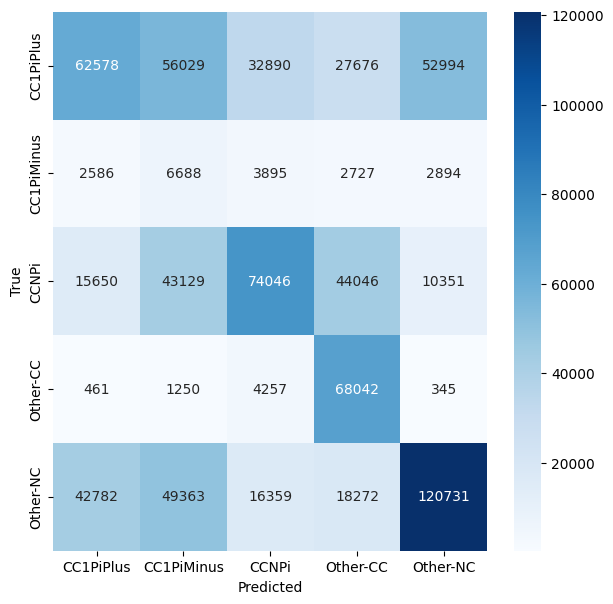

In [15]:
# 12 datasets: Make a 3x4 grid of confusion matrices
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
plot_confusion_matrix_on_ax(ax, results[model_to_plot][dataset_to_plot]["pid"], results[model_to_plot][dataset_to_plot]["prediction"].argmax(axis=1), labels_event_type)
fig.show()


In [16]:

def get_probabilities_single_pion_signal(model_to_plot, dataset_to_plot):
    remap = {0: 1, 1: 1, 2: 0, 3: 0, 4: 0}
    y_true = np.array([remap[x] for x in results[model_to_plot]["1A"]["pid"]])
    # Softmax over all 5 classes first, then sum probabilities for grouped classes
    all_logits = results[model_to_plot]["1A"]["prediction"]
    # apply softmax if omnilearned not in name, otherwise we already are expecting probabilities
    #if "omnilearn" not in model_to_plot.lower():
    #    all_probs = np.exp(all_logits) / np.sum(np.exp(all_logits), axis=1, keepdims=True)
    #else:
    all_probs = all_logits
    #    print("Using raw probs for", model_to_plot)
    # Positive: classes 0 (CC1Pi+) and 1 (CC1Pi-)
    y_pred = all_probs[:, 0] + all_probs[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
    return precision, recall, thresholds

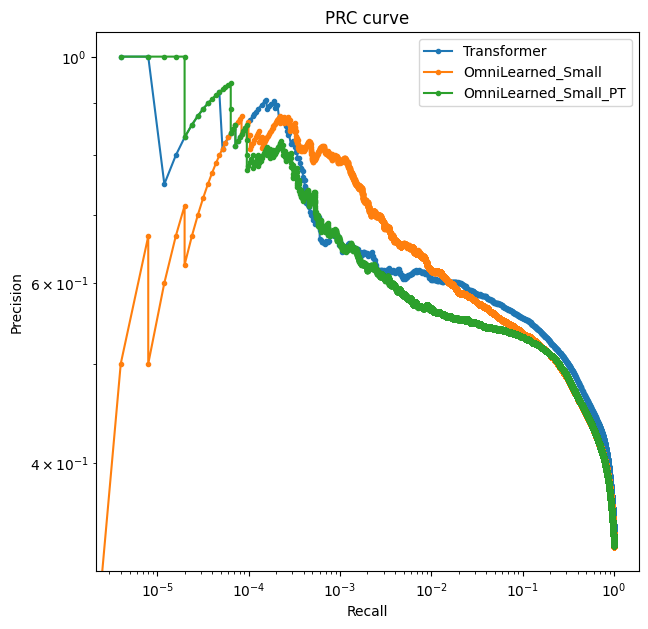

In [17]:
# Plot PRC Curve - 65 % events are positive

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
for model in results.keys():
    precision, recall, thresholds = get_probabilities_single_pion_signal(model, "1A")
    # precision_recall_curve returns len(precision) == len(thresholds) + 1; drop sentinel
    precision = precision[:-1]
    recall = recall[:-1]
    # Remove thresholds < 0.01 and > 0.99
    mask = (thresholds >= 0.01) & (thresholds <= 0.99)
    precision = precision[mask]
    recall = recall[mask]
    thresholds = thresholds[mask]
    ax.plot(recall, precision, ".-", label=model)
ax.legend()
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("PRC curve")
fig.show()

In [ ]:
p, r, t = get_probabilities_single_pion_signal("OmniLearned_Small", "1A")

In [32]:
p[-50:]

array([0.83673469, 0.83333333, 0.82978723, 0.82608696, 0.82222222,
       0.81818182, 0.81395349, 0.83333333, 0.82926829, 0.825     ,
       0.84615385, 0.84210526, 0.83783784, 0.83333333, 0.82857143,
       0.82352941, 0.81818182, 0.8125    , 0.83870968, 0.83333333,
       0.86206897, 0.85714286, 0.85185185, 0.84615385, 0.84      ,
       0.875     , 0.86956522, 0.86363636, 0.85714286, 0.85      ,
       0.84210526, 0.83333333, 0.82352941, 0.8125    , 0.8       ,
       0.78571429, 0.76923077, 0.75      , 0.72727273, 0.7       ,
       0.66666667, 0.625     , 0.71428571, 0.66666667, 0.6       ,
       0.5       , 0.66666667, 0.5       , 0.        , 1.        ])

In [28]:
pion_four_vector_MC = truth_labels["1pi_classification"]["1A_Transformer"]["1A"][:, -4:]
pion_E_MC = pion_four_vector_MC[:, 0] / 1000.0

KeyError: '1pi_classification'

In [31]:
# Make an efficiency plot vs GT pion energy

y_true = results["1pi_classification"]["1A_Transformer"]["1A"]["pid"]
y_pred = results["1pi_classification"]["1A_Transformer"]["1A"]["prediction"].argmax(axis=1)

np.bincount(y_pred)
# Remove cases where y_true or y_pred is 1 (no CC1PiMinus events...)
mask = (y_true != 1) & (y_pred != 1)
y_true = y_true[mask]
y_pred = y_pred[mask]

# Also, rewrite y_true to be 0, 1 instead of 0, 2
np.bincount(y_pred)
y_true = y_true == 2
y_pred =  results["1pi_classification"]["1A_Transformer"]["1A"]["prediction"][:, [0, 2]]

# There are only 1% positive labels in the dataset.
logits = results["1pi_classification"]["1A_Transformer"]["1A"]["prediction"][:, [0, 2]]
# Do a softmax
probs = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)
probs = probs[:, 1]


In [32]:
pion_E_MC_bins = np.array([0, 0.5, 0.75, 1.0, 2.0])
bin_middles = (pion_E_MC_bins[:-1] + pion_E_MC_bins[1:]) / 2
thresholds = np.linspace(0.5, 0.9, 10)
efficiency = {} # Threshold -> efficiency
purity = {} # Simply threshold -> Purity of the selected events (there is no pion mass involved)
for threshold in thresholds:
    efficiency[threshold] = []
    # Purity is percentage of selected events that have GT label 1
    mask = probs > threshold
    if mask.sum().item() > 0:
        purity[threshold] = y_true[mask].sum().item() / mask.sum().item()
    else:
        purity[threshold] = 0
    for i in range(len(pion_E_MC_bins) - 1):
        mask = (pion_E_MC > pion_E_MC_bins[i]) & (pion_E_MC <= pion_E_MC_bins[i+1])
        N_GT_pions = mask.sum().item()
        #print("N pions in bin", i, mask.sum().item())
        mask = mask & (probs > threshold)
        mask_sum = mask.sum().item()    
        if N_GT_pions > 0:
            efficiency[threshold].append(mask_sum / N_GT_pions)
        else:
            efficiency[threshold].append(0)


/tmp/ipykernel_599994/3569644144.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask = mask & (probs > threshold)


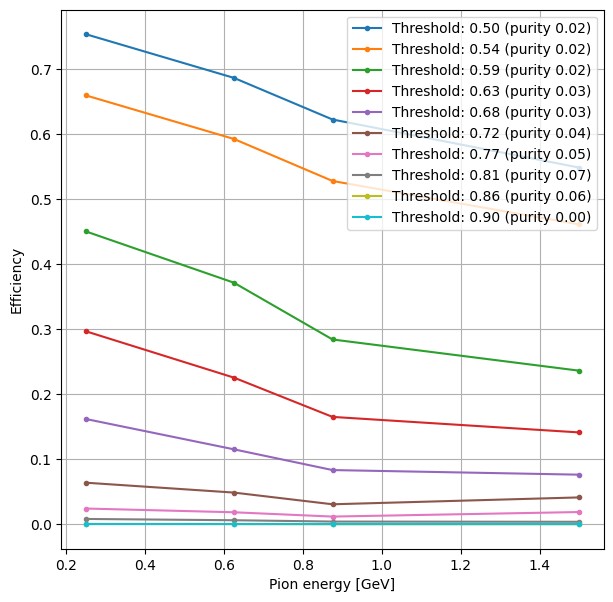

In [33]:
# Now, make a plot of pion energy (middle of bin) vs efficiency for each threshold
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
for threshold in thresholds:
    ax.plot(bin_middles, efficiency[threshold], ".-", label=f"Threshold: {threshold:.2f} (purity {purity[threshold]:.2f})")
ax.legend()
ax.set_xlabel("Pion energy [GeV]")
ax.set_ylabel("Efficiency")
ax.grid()

array([0.4995, 0.4277, 0.509 , ..., 0.3909, 0.255 , 0.3   ],
      shape=(760041,), dtype=float16)